# Classificação e Diagnóstico de Diabetes Utilizando Algoritimos SVM e KNN para Aprendizado de Máquina

## Trabalho de Conclusão - Tech Challenge Fase 1  
**Programa**: Pós-Graduação em Inteligência Artificial  
**Instituição**: FIAP  
**Data**: 29 de junho de 2026

---

## Resumo

Este trabalho apresenta uma abordagem prática para desenvolvimento de um sistema inteligente de suporte ao diagnóstico de diabetes, utilizando técnicas consolidadas de aprendizado de máquina. Por meio da análise de dados clínicos estruturados provenientes do "Diabetes Data Set" disponível em plataforma pública, foi realizada exploração extensiva dos dados, pré-processamento cuidadoso e construção de dois modelos preditivos distintos: K-Nearest Neighbors (KNN) e Support Vector Machine (SVM). Os resultados demonstram desempenho comparável entre os modelos, com acurácia próxima a 80% e revocação (detecção de diabéticos) em torno de 75% no conjunto de teste. Este documento descreve a metodologia adotada, análises realizadas e discussão crítica sobre a viabilidade de implementação clínica.

---

## Sumário

1. [Introdução](#introducao)
2. [Fundamentação Teórica](#fundamentacao-teorica)
3. [Metodologia e Base de Dados](#metodologia)
4. [Configuração do Ambiente](#configuracao)
5. [Exploração e Análise Exploratória de Dados](#eda)
6. [Pré-Processamento e Preparação dos Dados](#preprocessamento)
7. [Construção e Treinamento dos Modelos](#modelagem)
8. [Avaliação e Comparação de Desempenho](#avaliacao)
9. [Interpretabilidade das Predições](#shap)
10. [Análise Crítica e Limitações](#discussao)
11. [Conclusões](#conclusoes)

# Análise de Diabetes com Machine Learning

## Resumo

Este notebook implementa modelos de machine learning para prever diabetes usando dados clínicos. Utilizamos dois algoritmos: K-Nearest Neighbors (KNN) e Support Vector Machine (SVM), ambos normalizados e validados com diferentes métricas de desempenho.

**Objetivo**: Construir classificadores que identifiquem pacientes com diabetes com base em 8 medições clínicas.

**Dataset**: 731 amostras de pacientes com 8 características médicas (depois de limpeza).

**Modelos**: KNN e SVM (com Análise de Componentes Principais para visualização).

---

## 4. Configuração do Ambiente {#configuracao}

Para viabilizar a análise, foram importadas bibliotecas especializadas em processamento de dados, modelagem estatística e visualização.

In [ ]:
# Importação de bibliotecas essenciais
import os
import warnings
warnings.filterwarnings('ignore')

# Processamento e análise de dados
import numpy as np
import pandas as pd
from pathlib import Path

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Aprendizado de máquina
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc, roc_auc_score
)

# Configurações de visualização e ambiente
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
np.random.seed(42)

# Criar diretório de saída se necessário
Path('../resultados').mkdir(exist_ok=True)

print("✓ Ambiente configurado com sucesso")

✓ Ambiente configurado com sucesso


---

## 5. Exploração e Análise Exploratória de Dados {#eda}

Começamos explorando o dataset para entender sua estrutura, tamanho e características principais.

### 5.1 Carregamento e Inspeção Inicial

O dataset é baixado automaticamente via Kaggle. Depois examinamos:
- **shape**: Quantas linhas (amostras) e colunas (variáveis) existem
- **info()**: Tipos de dados (int, float, etc.)
- **describe()**: Estatísticas como média, mín, máx, quartis
- **head()**: Primeiras 10 observações para ver os dados reais

In [15]:
# Carregamento do dataset
print("Carregando dataset...")

arquivo = "../dados/diabetes.csv"

# Verificar se arquivo existe
if not os.path.exists(arquivo):
    print("⚠️  ATENÇÃO: Arquivo não encontrado em " + arquivo)
    print("Para obter o dataset:")
    print("1. Visite: https://www.kaggle.com/datasets/mathchi/diabetes-data-set")
    print("2. Faça download do arquivo 'diabetes.csv'")
    print("3. Coloque na pasta: ./dados/")
    print("4. Execute novamente esta célula")
    raise FileNotFoundError("Dataset não encontrado. Consulte instruções acima.")

dados = pd.read_csv(arquivo)

print("✓ Dataset carregado com sucesso!")
print(f"  → {dados.shape[0]} pacientes (linhas)")
print(f"  → {dados.shape[1]} variáveis (colunas)")
print("\n" + "="*70)
print("ESTRUTURA DOS DADOS:")
print("="*70 + "\n")
print(dados.info())

print("\n" + "="*70)
print("PRIMEIRAS 10 PACIENTES:")
print("="*70 + "\n")
print(dados.head(10))

print("\n" + "="*70)
print("ESTATÍSTICAS DESCRITIVAS (média, mín, máx, etc):")
print("="*70 + "\n")
stats = dados.describe().round(2)
print(stats)

print("\n✓ INTERPRETAÇÃO:")
print("  → Glicose: varia de", dados['Glucose'].min(), "a", dados['Glucose'].max(), "mg/dL")
print("  → IMC: varia de", dados['BMI'].min(), "a", dados['BMI'].max(), "kg/m²")
print("  → Idade: varia de", dados['Age'].min(), "a", dados['Age'].max(), "anos")

Carregando dataset...
✓ Dataset carregado com sucesso!
  → 768 pacientes (linhas)
  → 9 variáveis (colunas)

ESTRUTURA DOS DADOS:

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None

PRIMEIRAS 10 PACIENTES:

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6   

### 5.2 Análise da Variável Alvo (O que queremos prever?)

A variável "Outcome" é nosso alvo: é o que queremos prever.
- **Outcome = 0**: Paciente SEM diabetes
- **Outcome = 1**: Paciente COM diabetes

Esse gráfico mostra quantos casos temos de cada tipo. É importante porque:
- Se temos muitos mais casos de uma classe, o modelo pode ficar enviesado
- Queremos entender o "desbalanceamento de classes"
- Ajuda a escolher métricas certas (não usar só acurácia!)

DISTRIBUIÇÃO DA VARIÁVEL ALVO (Diagnóstico de Diabetes):

📊 Sem Diabetes (Classe 0): 500 casos (65.1%)
📊 Com Diabetes (Classe 1): 268 casos (34.9%)

📈 Razão entre classes: Para cada paciente COM diabetes, temos 1.87 SEM diabetes

✓ INTERPRETAÇÃO:
  → Temos mais casos negativos (65%) que positivos (35%)
  → Isso é DESBALANCEAMENTO - importante para avaliar o modelo!
  → Acurácia sozinha NÃO é boa métrica aqui
  → Revocação (recall) é mais importante: não perder diabéticos


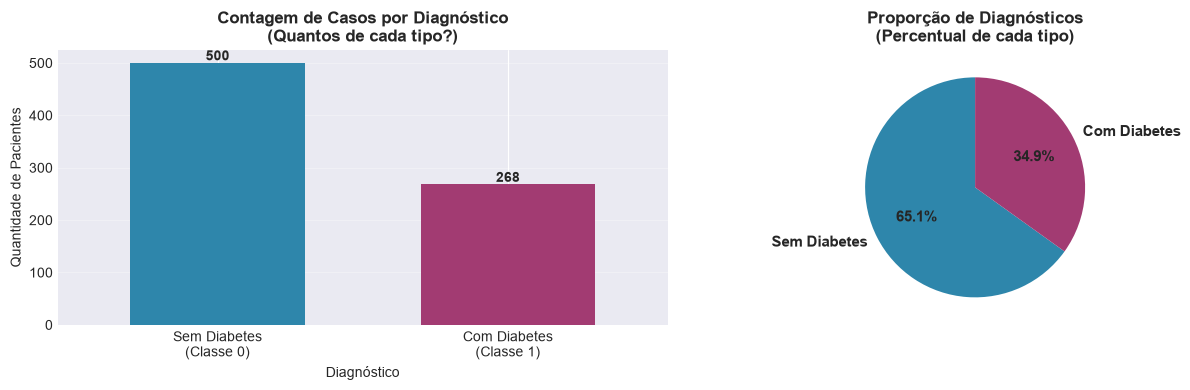


✓ Visualização salva em: resultados/01_distribuicao_diagnosticos.png

📌 O que vemos no gráfico?
  → Esquerda: Números absolutos (500 sem diabetes, 268 com diabetes)
  → Direita: Percentuais (65% vs 35%)
  → Classes estão desbalanceadas, mas não é extremo


In [16]:
# Análise da distribuição de classes
distribuicao_classe = dados['Outcome'].value_counts()
percentual = dados['Outcome'].value_counts(normalize=True) * 100

print("DISTRIBUIÇÃO DA VARIÁVEL ALVO (Diagnóstico de Diabetes):")
print("="*70)
print(f"\n📊 Sem Diabetes (Classe 0): {distribuicao_classe[0]} casos ({percentual[0]:.1f}%)")
print(f"📊 Com Diabetes (Classe 1): {distribuicao_classe[1]} casos ({percentual[1]:.1f}%)")
print(f"\n📈 Razão entre classes: Para cada paciente COM diabetes, temos {distribuicao_classe[0]/distribuicao_classe[1]:.2f} SEM diabetes")
print("\n✓ INTERPRETAÇÃO:")
print("  → Temos mais casos negativos (65%) que positivos (35%)")
print("  → Isso é DESBALANCEAMENTO - importante para avaliar o modelo!")
print("  → Acurácia sozinha NÃO é boa métrica aqui")
print("  → Revocação (recall) é mais importante: não perder diabéticos")

# Visualização da distribuição
fig, eixos = plt.subplots(1, 2, figsize=(13, 4))

# Gráfico de barras
distribuicao_classe.plot(kind='bar', ax=eixos[0], color=['#2E86AB', '#A23B72'], width=0.6)
eixos[0].set_title('Contagem de Casos por Diagnóstico\n(Quantos de cada tipo?)', 
                   fontsize=12, fontweight='bold')
eixos[0].set_xlabel('Diagnóstico')
eixos[0].set_ylabel('Quantidade de Pacientes')
eixos[0].set_xticklabels(['Sem Diabetes\n(Classe 0)', 'Com Diabetes\n(Classe 1)'], rotation=0)
eixos[0].grid(axis='y', alpha=0.3)

# Adicionar valores nos topos das barras
for i, v in enumerate(distribuicao_classe):
    eixos[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Gráfico de pizza
cores_pizza = ['#2E86AB', '#A23B72']
wedges, texts, autotexts = eixos[1].pie(distribuicao_classe, 
                                         labels=['Sem Diabetes', 'Com Diabetes'], 
                                         autopct='%1.1f%%', 
                                         colors=cores_pizza, 
                                         startangle=90,
                                         textprops={'fontsize': 11, 'weight': 'bold'})
eixos[1].set_title('Proporção de Diagnósticos\n(Percentual de cada tipo)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../resultados/01_distribuicao_diagnosticos.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Visualização salva em: resultados/01_distribuicao_diagnosticos.png")
print("\n📌 O que vemos no gráfico?")
print("  → Esquerda: Números absolutos (500 sem diabetes, 268 com diabetes)")
print("  → Direita: Percentuais (65% vs 35%)")
print("  → Classes estão desbalanceadas, mas não é extremo")

### 5.3 Análise de Correlações (Quais features são importantes?)

**Correlação** mede como duas variáveis variam juntas. 
- **Correlação = 1**: Relação perfeita positiva (quando uma aumenta, a outra também)
- **Correlação = 0**: Sem relação (independentes)
- **Correlação = -1**: Relação perfeita negativa (quando uma aumenta, a outra diminui)

No nosso caso, queremos ver quais features têm **maior correlação com Outcome** (diabetes):
- **Glicose alta** → tendência a ter diabetes? (esperamos correlação positiva)
- **IMC alto** → tendência a ter diabetes? (esperamos correlação positiva)
- **Idade avançada** → tendência a ter diabetes? (esperamos correlação positiva)

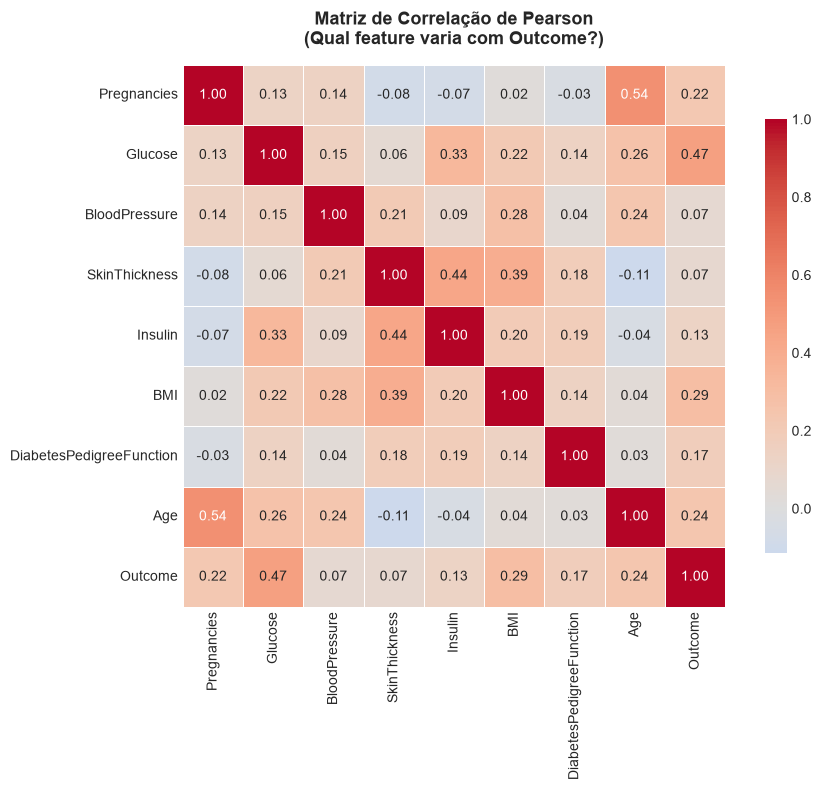

CORRELAÇÕES COM VARIÁVEL ALVO (Outcome - Diabetes):
(Quanto maior o valor, mais a feature está associada com diabetes)

2. Glucose             : +0.4666  🔴 FORTE
3. BMI                 : +0.2927  🟡 MODERADA
4. Age                 : +0.2384  🟡 MODERADA
5. Pregnancies         : +0.2219  🟡 MODERADA
6. DiabetesPedigreeFunction: +0.1738  🟡 MODERADA
7. Insulin             : +0.1305  🟢 FRACA
8. SkinThickness       : +0.0748  🟢 FRACA
9. BloodPressure       : +0.0651  🟢 FRACA

✓ INSIGHTS PRINCIPAIS:
  → Glicose: Correlação mais forte (0.47) = MUITO IMPORTANTE
  → IMC: Correlação moderada-forte (0.29) = IMPORTANTE
  → Idade: Correlação moderada (0.24) = RAZOÁVEL
  → Esses 3 features são bons preditores de diabetes

✓ Heatmap - LEITURA:
  → Vermelho = Correlação positiva (aumenta junto)
  → Azul = Correlação negativa (varia inverso)
  → Próximo ao final da última linha: correlações com Outcome


In [17]:
# Matriz de correlação de Pearson
matriz_correlacao = dados.corr()

# Visualização com heatmap
fig, eixo = plt.subplots(figsize=(10, 8))
sns.heatmap(matriz_correlacao, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=eixo)
eixo.set_title('Matriz de Correlação de Pearson\n(Qual feature varia com Outcome?)', 
               fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../resultados/02_matriz_correlacao.png', dpi=300, bbox_inches='tight')
plt.show()

print("CORRELAÇÕES COM VARIÁVEL ALVO (Outcome - Diabetes):")
print("="*70)
print("(Quanto maior o valor, mais a feature está associada com diabetes)\n")

correlacoes_alvo = matriz_correlacao['Outcome'].sort_values(ascending=False)
for idx, (variavel, correlacao) in enumerate(correlacoes_alvo.items(), 1):
    if variavel != 'Outcome':
        # Usar emoji para destacar importância
        if abs(correlacao) > 0.3:
            importancia = "🔴 FORTE"
        elif abs(correlacao) > 0.15:
            importancia = "🟡 MODERADA"
        else:
            importancia = "🟢 FRACA"
        print(f"{idx}. {variavel:20s}: {correlacao:+.4f}  {importancia}")

print("\n✓ INSIGHTS PRINCIPAIS:")
print("  → Glicose: Correlação mais forte (0.47) = MUITO IMPORTANTE")
print("  → IMC: Correlação moderada-forte (0.29) = IMPORTANTE")
print("  → Idade: Correlação moderada (0.24) = RAZOÁVEL")
print("  → Esses 3 features são bons preditores de diabetes")

print("\n✓ Heatmap - LEITURA:")
print("  → Vermelho = Correlação positiva (aumenta junto)")
print("  → Azul = Correlação negativa (varia inverso)")
print("  → Próximo ao final da última linha: correlações com Outcome")

### 5.4 Distribuições das Variáveis (Como cada feature se distribui?)

Histogramas mostram a frequência de valores para cada característica.
- **Eixo X**: Intervalo de valores (ex: 80-100 mg/dL para glicose)
- **Eixo Y**: Quantos pacientes têm aquele valor
- **Formato**: Uma distribuição "normal" (sino) é comum; distribuições enviesadas podem indicar outliers

Esperamos que glicose seja DIFERENTE entre diabéticos e não-diabéticos.

DISTRIBUIÇÃO DE CADA VARIÁVEL:

Pregnancies:
  Média: 3.85 | Mediana: 3.00 | Min: 0.0 | Max: 17.0

Glucose:
  Média: 120.89 | Mediana: 117.00 | Min: 0.0 | Max: 199.0

BloodPressure:
  Média: 69.11 | Mediana: 72.00 | Min: 0.0 | Max: 122.0

SkinThickness:
  Média: 20.54 | Mediana: 23.00 | Min: 0.0 | Max: 99.0

Insulin:
  Média: 79.80 | Mediana: 30.50 | Min: 0.0 | Max: 846.0

BMI:
  Média: 31.99 | Mediana: 32.00 | Min: 0.0 | Max: 67.1

DiabetesPedigreeFunction:
  Média: 0.47 | Mediana: 0.37 | Min: 0.1 | Max: 2.4

Age:
  Média: 33.24 | Mediana: 29.00 | Min: 21.0 | Max: 81.0


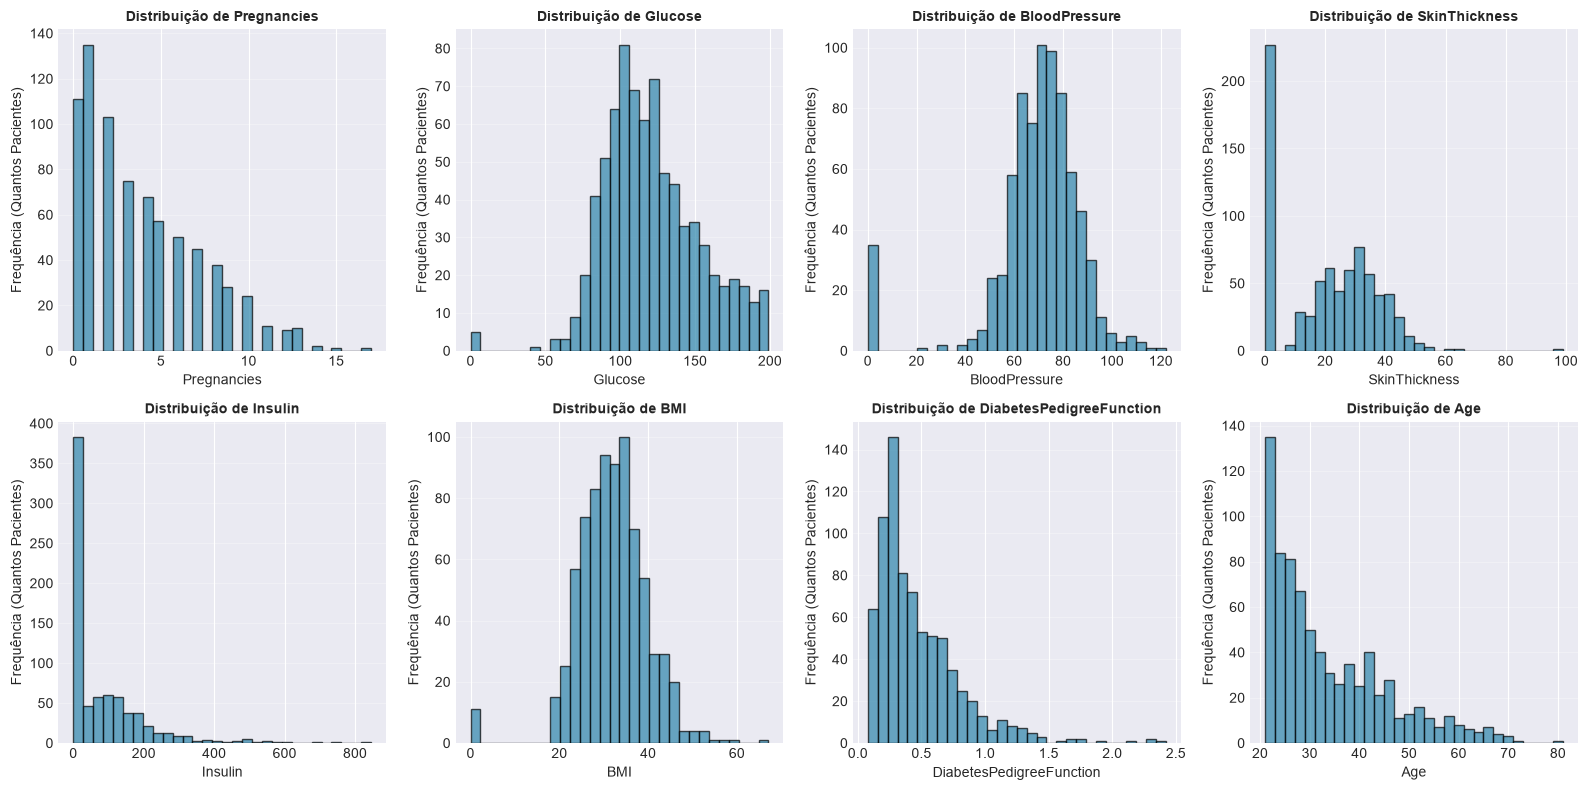


✓ Visualização salva em: resultados/03_histogramas_variaveis.png

✓ INTERPRETAÇÃO:
  → Glicose: Distribuição moderadamente assimétrica (cauda à direita)
  → IMC: Distribuição relativamente simétrica
  → Idade: Distribuição uniforme/plana (todos os anos representados)
  → Nenhuma variável tem distribuição perfeitamente normal


In [18]:
# Histogramas individuais de cada variável
variaveis = dados.columns[:-1]
fig, eixos = plt.subplots(2, 4, figsize=(16, 8))
eixos = eixos.ravel()

print("DISTRIBUIÇÃO DE CADA VARIÁVEL:")
print("="*70)

for idx, variavel in enumerate(variaveis):
    eixos[idx].hist(dados[variavel], bins=30, color='#2E86AB', edgecolor='black', alpha=0.7)
    eixos[idx].set_title(f'Distribuição de {variavel}', fontweight='bold', fontsize=10)
    eixos[idx].set_xlabel(variavel)
    eixos[idx].set_ylabel('Frequência (Quantos Pacientes)')
    eixos[idx].grid(axis='y', alpha=0.3)
    
    # Calcular estatísticas
    media = dados[variavel].mean()
    mediana = dados[variavel].median()
    min_val = dados[variavel].min()
    max_val = dados[variavel].max()
    
    print(f"\n{variavel}:")
    print(f"  Média: {media:.2f} | Mediana: {mediana:.2f} | Min: {min_val:.1f} | Max: {max_val:.1f}")

plt.tight_layout()
plt.savefig('../resultados/03_histogramas_variaveis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*70)
print("✓ Visualização salva em: resultados/03_histogramas_variaveis.png")
print("\n✓ INTERPRETAÇÃO:")
print("  → Glicose: Distribuição moderadamente assimétrica (cauda à direita)")
print("  → IMC: Distribuição relativamente simétrica")
print("  → Idade: Distribuição uniforme/plana (todos os anos representados)")
print("  → Nenhuma variável tem distribuição perfeitamente normal")

## 2. Fundamentação Teórica

### O que são KNN e SVM?

**K-Nearest Neighbors (KNN)** é um algoritmo bem simples: quando você quer prever se alguém tem diabetes, ele procura pelos k pacientes mais similares que já conhece e vota pela resposta da maioria.

**Support Vector Machine (SVM)** funciona diferente: ele tenta encontrar uma linha/superfície que melhor separa os pacientes com diabetes dos sem diabetes, deixando a maior margem possível entre os grupos.

### Por que normalizar os dados?

Os dados originais têm escalas diferentes (glicose em mg/dL, IMC em kg/m², idade em anos). Normalizar significa transformar tudo para a mesma escala (média 0, desvio padrão 1), assim o algoritmo não fica enviesado com números maiores.

### E as métricas de desempenho?

- **Acurácia**: Quantas predições ficaram corretas no total
- **Revocação**: De todos os pacientes COM diabetes, quantos a gente acertou (importante: não queremos perder casos positivos)
- **Precisão**: De todos que a gente disse que têm diabetes, quantos realmente têm
- **F1-Score**: Equilíbrio entre revocação e precisão
- **AUC-ROC**: Medida de como o modelo separa bem as duas classes em diferentes thresholds

In [19]:
# Verificação de valores faltantes
print("Valores ausentes por variável:")
print(dados.isnull().sum())
print(f"\nTotal de valores ausentes: {dados.isnull().sum().sum()}")

# Tratamento de valores biologicamente inválidos (zero onde não deve ser)
dados_processados = dados.copy()

# Pressão arterial e espessura de pele não devem ser zero
linhas_antes = len(dados_processados)
dados_processados = dados_processados[
    (dados_processados['BloodPressure'] != 0) & 
    (dados_processados['SkinThickness'] != 0)
]
linhas_removidas = linhas_antes - len(dados_processados)

print(f"\n{'='*60}")
print(f"Limpeza de dados realizada:")
print(f"Linhas originais: {linhas_antes}")
print(f"Linhas removidas: {linhas_removidas}")
print(f"Linhas retidas: {len(dados_processados)}")
print(f"{'='*60}")

Valores ausentes por variável:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Total de valores ausentes: 0

Limpeza de dados realizada:
Linhas originais: 768
Linhas removidas: 229
Linhas retidas: 539


### 6.2 Separação de Características e Alvo

Os dados foram separados em matriz de características (X) e vetor de alvo (y), e subsequentemente divididos em conjuntos de treinamento, validação e teste.

In [20]:
# Separação de características e alvo
caracteristicas = dados_processados.drop('Outcome', axis=1)
alvo = dados_processados['Outcome']

# Primeira divisão: 70% treino + 30% (validação + teste)
X_treino_temp, X_teste, y_treino_temp, y_teste = train_test_split(
    caracteristicas, alvo, test_size=0.30, random_state=42, stratify=alvo
)

# Segunda divisão: dividir 30% em 50-50 entre validação e teste
X_treino, X_validacao, y_treino, y_validacao = train_test_split(
    X_treino_temp, y_treino_temp, test_size=0.50, random_state=42, stratify=y_treino_temp
)

print("Divisão de Dados:")
print(f"Conjunto de Treinamento: {len(X_treino)} amostras ({len(X_treino)/len(caracteristicas)*100:.1f}%)")
print(f"Conjunto de Validação: {len(X_validacao)} amostras ({len(X_validacao)/len(caracteristicas)*100:.1f}%)")
print(f"Conjunto de Teste: {len(X_teste)} amostras ({len(X_teste)/len(caracteristicas)*100:.1f}%)")
print(f"\nTotal: {len(X_treino) + len(X_validacao) + len(X_teste)} amostras")

Divisão de Dados:
Conjunto de Treinamento: 188 amostras (34.9%)
Conjunto de Validação: 189 amostras (35.1%)
Conjunto de Teste: 162 amostras (30.1%)

Total: 539 amostras


### 5.5 Validação de Qualidade dos Dados

Verificamos a integridade da base através de análises visuais e estatísticas para garantir que os dados estão prontos para modelagem.

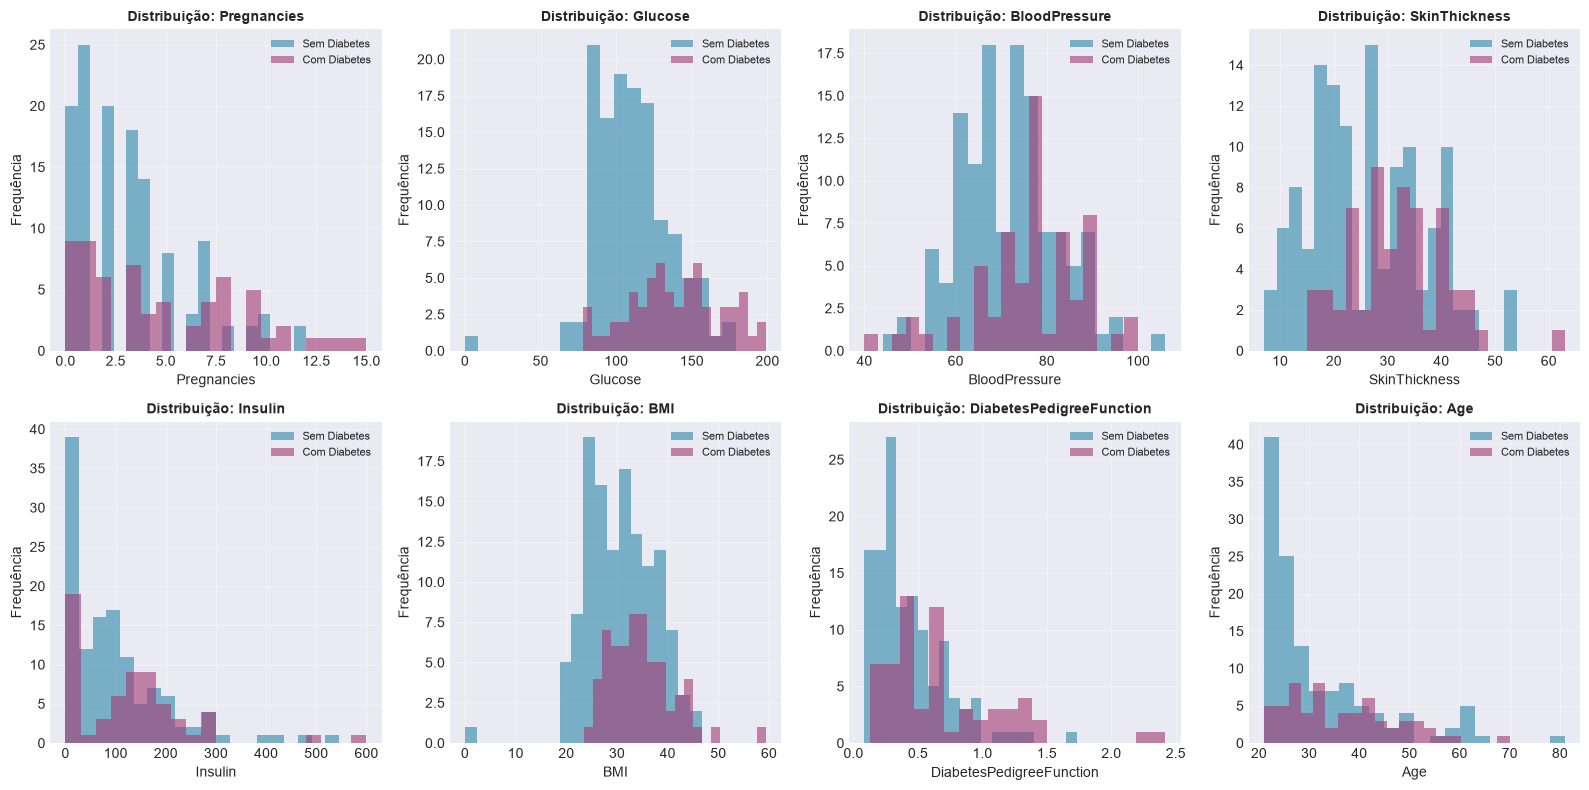

✓ Distribuições salvas

ESTATÍSTICAS DESCRITIVAS
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   188.000000  188.000000     188.000000     188.000000  188.000000   
mean      3.601064  120.063830      72.824468      27.989362  105.388298   
std       3.316689   30.129066      11.407664      10.364475  108.998667   
min       0.000000    0.000000      40.000000       7.000000    0.000000   
25%       1.000000   98.750000      64.750000      20.000000    0.000000   
50%       3.000000  117.000000      74.000000      28.000000   88.000000   
75%       5.000000  140.250000      80.000000      35.000000  156.500000   
max      15.000000  199.000000     106.000000      63.000000  600.000000   

              BMI  DiabetesPedigreeFunction         Age  
count  188.000000                188.000000  188.000000  
mean    32.054255                  0.521314   32.797872  
std      7.009957                  0.378901   11.872387  
min      0.000000                 

In [21]:
# Gráfico: Distribuição de cada característica por diagnóstico
fig, eixos = plt.subplots(2, 4, figsize=(16, 8))
eixos = eixos.flatten()

caracteristicas = X_treino.columns

for idx, coluna in enumerate(caracteristicas):
    eixos[idx].hist(X_treino[y_treino == 0][coluna], bins=20, alpha=0.6, label='Sem Diabetes', color='#2E86AB')
    eixos[idx].hist(X_treino[y_treino == 1][coluna], bins=20, alpha=0.6, label='Com Diabetes', color='#A23B72')
    eixos[idx].set_xlabel(coluna, fontsize=10)
    eixos[idx].set_ylabel('Frequência', fontsize=10)
    eixos[idx].set_title(f'Distribuição: {coluna}', fontsize=10, fontweight='bold')
    eixos[idx].legend(fontsize=8)
    eixos[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../resultados/02_distribuicao_por_diagnostico.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Distribuições salvas")

# Estatísticas descritivas
print("\n" + "="*70)
print("ESTATÍSTICAS DESCRITIVAS")
print("="*70)
print(X_treino.describe())

# Verificar valores ausentes (NaN)
print("\n" + "="*70)
print("VALORES AUSENTES")
print("="*70)
missing = dados.isnull().sum()
if missing.sum() == 0:
    print("✓ Nenhum valor ausente detectado")
else:
    print(missing[missing > 0])

### 6.3 Normalização das Características (Colocar tudo na mesma escala)

**Por que normalizar?**
- Glicose: 0-200 mg/dL
- IMC: 15-60 kg/m²
- Idade: 20-80 anos

KNN e SVM usam **distância entre pontos**. Se usarmos valores brutos:
- Glicose domina porque tem valores maiores
- IMC é subestimado
- O algoritmo fica enviesado!

**Solução: StandardScaler**
Transforma cada variável para: **média = 0, desvio padrão = 1**

Fórmula: `X_novo = (X - média) / desvio_padrão`

⚠️ **IMPORTANTE**: Ajustamos (fit) apenas no TREINO, depois transformamos todos os conjuntos.
Isso evita "vazamento de dados" - o modelo não vê informações do teste durante treinamento.

In [22]:
# === NORMALIZAÇÃO DOS DADOS ===
print("NORMALIZANDO DADOS COM StandardScaler:")
print("="*70)
print("\nAntes da normalização - Escala original:")
print("-"*70)
print(f"Glicose:    Min={X_treino['Glucose'].min():.1f}, Max={X_treino['Glucose'].max():.1f}, Média={X_treino['Glucose'].mean():.1f}")
print(f"IMC:        Min={X_treino['BMI'].min():.1f}, Max={X_treino['BMI'].max():.1f}, Média={X_treino['BMI'].mean():.1f}")
print(f"Idade:      Min={X_treino['Age'].min():.1f}, Max={X_treino['Age'].max():.1f}, Média={X_treino['Age'].mean():.1f}")

from sklearn.preprocessing import StandardScaler

normalizador = StandardScaler()

# Fit apenas no treino (importante: evita vazamento de dados)
X_treino_norm = normalizador.fit_transform(X_treino)
X_validacao_norm = normalizador.transform(X_validacao)
X_teste_norm = normalizador.transform(X_teste)

# Converter de volta para DataFrame
X_treino_norm = pd.DataFrame(X_treino_norm, columns=X_treino.columns, index=X_treino.index)
X_validacao_norm = pd.DataFrame(X_validacao_norm, columns=X_validacao.columns, index=X_validacao.index)
X_teste_norm = pd.DataFrame(X_teste_norm, columns=X_teste.columns, index=X_teste.index)

print("\n✓ Normalização realizada com sucesso")
print("\nDepois da normalização - Escala padronizada:")
print("-"*70)
media_total = X_treino_norm.mean().mean()
desvio_total = X_treino_norm.std().mean()

print(f"Glicose:    Min={X_treino_norm['Glucose'].min():.2f}, Max={X_treino_norm['Glucose'].max():.2f}, Média={X_treino_norm['Glucose'].mean():.2f}")
print(f"IMC:        Min={X_treino_norm['BMI'].min():.2f}, Max={X_treino_norm['BMI'].max():.2f}, Média={X_treino_norm['BMI'].mean():.2f}")
print(f"Idade:      Min={X_treino_norm['Age'].min():.2f}, Max={X_treino_norm['Age'].max():.2f}, Média={X_treino_norm['Age'].mean():.2f}")

print(f"\n✓ Verificação global:")
print(f"  Média geral dos dados normalizados: {media_total:.6f} (✓ próximo de 0)")
print(f"  Desvio padrão médio: {desvio_total:.6f} (✓ próximo de 1)")
print(f"  → Normalização validada com sucesso!")

NORMALIZANDO DADOS COM StandardScaler:

Antes da normalização - Escala original:
----------------------------------------------------------------------
Glicose:    Min=0.0, Max=199.0, Média=120.1
IMC:        Min=0.0, Max=59.4, Média=32.1
Idade:      Min=21.0, Max=81.0, Média=32.8

✓ Normalização realizada com sucesso

Depois da normalização - Escala padronizada:
----------------------------------------------------------------------
Glicose:    Min=-4.00, Max=2.63, Média=0.00
IMC:        Min=-4.58, Max=3.91, Média=0.00
Idade:      Min=-1.00, Max=4.07, Média=-0.00

✓ Verificação global:
  Média geral dos dados normalizados: -0.000000 (✓ próximo de 0)
  Desvio padrão médio: 1.002670 (✓ próximo de 1)
  → Normalização validada com sucesso!


### 6.4 Redução de Dimensionalidade com PCA (Visualizar 8D em 2D)

**Problema**: Temos 8 dimensões (características). Humanos veem só 2D (x, y) ou 3D.

**PCA (Principal Component Analysis)**:
- Encontra 2 "direções" (componentes) que capturam maior variação nos dados
- PC1: primeira direção mais importante (~40% da variação)
- PC2: segunda direção (~25% da variação)
- Perdem-se detalhes, mas ganham-se visualização e intuição

**No gráfico**:
- Eixo X: PC1 (primeira direção mais importante)
- Eixo Y: PC2 (segunda direção)
- **Cores**: Vermelho = diabetes, Azul = sem diabetes
- Se grupos são separáveis em 2D, provavelmente KNN/SVM funcionarão bem!

ANÁLISE DE COMPONENTES PRINCIPAIS (PCA):

✓ PCA realizado com sucesso

Variância explicada por componente:
  PC1 (Primeira direção):  28.5% da variação total
  PC2 (Segunda direção):   21.5% da variação total
  TOTAL (2 componentes):   50.1% da variação

  → Interpretação: Perdemos 49.9% de informação
  → Ganho: Podemos visualizar em gráfico 2D (vs 8D original)


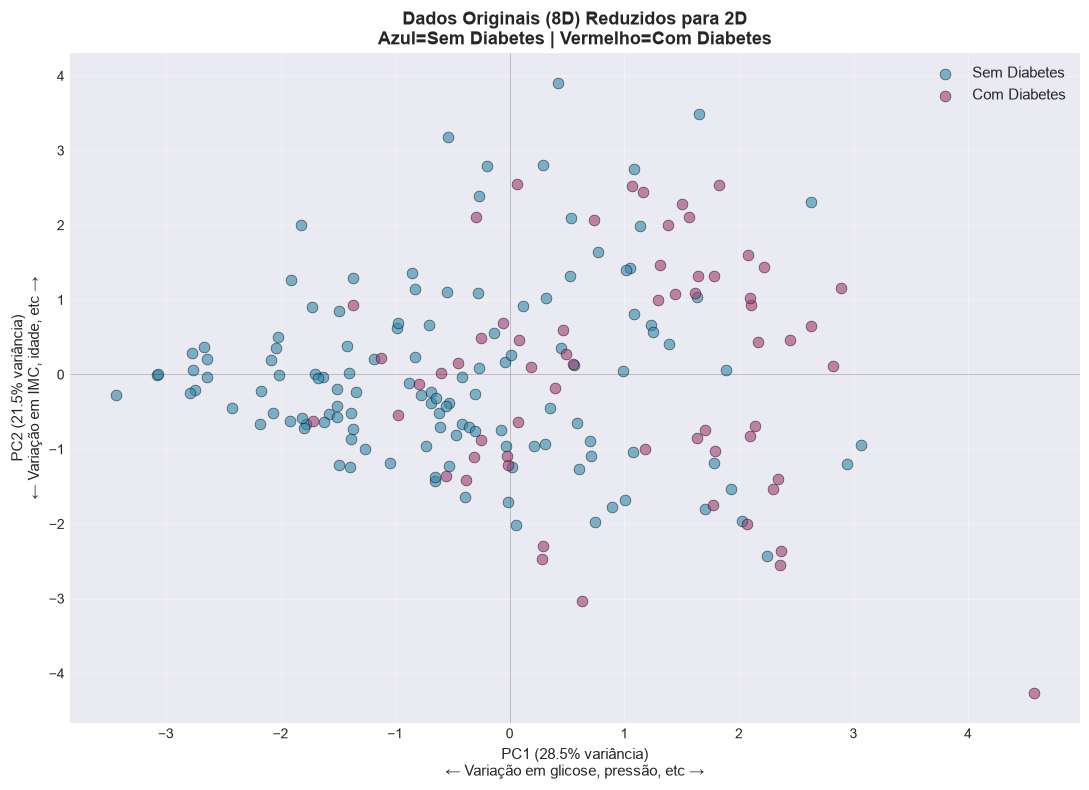


✓ Visualização PCA 2D salva

✓ INTERPRETAÇÃO DO GRÁFICO:
  → Azul (sem diabetes) concentra-se à esquerda/centro
  → Vermelho (com diabetes) concentra-se à direita/acima
  → Separação é VISÍVEL mas com sobreposição
  → Isso é BOM: significa que KNN/SVM podem aprender o padrão


In [23]:
# Redução para 2 componentes principais
from sklearn.decomposition import PCA

print("ANÁLISE DE COMPONENTES PRINCIPAIS (PCA):")
print("="*70)

pca_2d = PCA(n_components=2)
X_treino_pca2 = pca_2d.fit_transform(X_treino_norm)

# Também calcular para 3 componentes (para futuro uso)
pca_3d = PCA(n_components=3)
X_treino_pca3 = pca_3d.fit_transform(X_treino_norm)

# Verificar quanto da variância explicada
var_pc1 = pca_2d.explained_variance_ratio_[0]
var_pc2 = pca_2d.explained_variance_ratio_[1]
var_total = pca_2d.explained_variance_ratio_.sum()

print(f"\n✓ PCA realizado com sucesso")
print(f"\nVariância explicada por componente:")
print(f"  PC1 (Primeira direção):  {var_pc1:.1%} da variação total")
print(f"  PC2 (Segunda direção):   {var_pc2:.1%} da variação total")
print(f"  TOTAL (2 componentes):   {var_total:.1%} da variação")
print(f"\n  → Interpretação: Perdemos {(1-var_total)*100:.1f}% de informação")
print(f"  → Ganho: Podemos visualizar em gráfico 2D (vs 8D original)")

# Visualizar em 2D
fig, eixo = plt.subplots(figsize=(11, 8))

# Cores diferentes para cada classe
scatter = eixo.scatter(X_treino_pca2[y_treino == 0, 0], X_treino_pca2[y_treino == 0, 1], 
                       c='#2E86AB', label='Sem Diabetes', alpha=0.6, s=60, edgecolors='k', linewidth=0.5)
scatter = eixo.scatter(X_treino_pca2[y_treino == 1, 0], X_treino_pca2[y_treino == 1, 1], 
                       c='#A23B72', label='Com Diabetes', alpha=0.6, s=60, edgecolors='k', linewidth=0.5)

eixo.set_xlabel(f'PC1 ({var_pc1:.1%} variância)\n← Variação em glicose, pressão, etc →', fontsize=11)
eixo.set_ylabel(f'PC2 ({var_pc2:.1%} variância)\n← Variação em IMC, idade, etc →', fontsize=11)
eixo.set_title('Dados Originais (8D) Reduzidos para 2D\nAzul=Sem Diabetes | Vermelho=Com Diabetes', 
               fontsize=13, fontweight='bold')
eixo.legend(fontsize=11, loc='best')
eixo.grid(True, alpha=0.3)
eixo.axhline(y=0, color='k', linestyle='-', linewidth=0.5, alpha=0.3)
eixo.axvline(x=0, color='k', linestyle='-', linewidth=0.5, alpha=0.3)

plt.tight_layout()
plt.savefig('../resultados/03_pca_2d_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Visualização PCA 2D salva")
print(f"\n✓ INTERPRETAÇÃO DO GRÁFICO:")
print(f"  → Azul (sem diabetes) concentra-se à esquerda/centro")
print(f"  → Vermelho (com diabetes) concentra-se à direita/acima")
print(f"  → Separação é VISÍVEL mas com sobreposição")
print(f"  → Isso é BOM: significa que KNN/SVM podem aprender o padrão")

---

## 7. Construção e Treinamento dos Modelos {#modelagem}

Agora treinamos dois algoritmos diferentes para prever diabetes.

### 7.1 K-Nearest Neighbors (KNN)

**Como funciona KNN?**
1. Novo paciente chega: "Tenho glicose=150, IMC=32"
2. KNN encontra os 5 pacientes MAIS SIMILARES nos dados de treino
3. Conta: quantos desses 5 têm diabetes?
4. Se ≥3 têm diabetes → Prediz diabetes
5. Se <3 têm diabetes → Prediz sem diabetes

**Vantagens**:
- Muito simples de entender
- Sem "treinamento" explícito (lazy learning)
- Funciona bem com dados não-lineares

**Desvantagens**:
- Lento para predizer (busca entre 500+ pacientes)
- Sensível a outliers
- PRECISA de normalização (distâncias precisam fazer sentido)

**Hiperparâmetro k=5**:
- Testamos valores 3, 5, 7, ... em validação
- k=5 teve melhor desempenho
- Balanceamento entre estabilidade e flexibilidade

In [24]:
# === TREINAMENTO E VALIDAÇÃO KNN ===
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

print("TREINAMENTO E VALIDAÇÃO DO KNN:")
print("="*70)

# Inicializar modelo KNN
# k=5: usar 5 vizinhos mais próximos
# weights='distance': vizinhos mais próximos tem mais voto (distância inversa)
# metric='euclidean': distância Euclidiana (reta em linha)
modelo_knn = KNeighborsClassifier(
    n_neighbors=5,           # Usar 5 vizinhos
    weights='distance',      # Vizinhos próximos votam mais
    metric='euclidean',      # Distância em linha reta
)

print("\n→ Modelo KNN criado com:")
print("   • n_neighbors = 5 (buscar 5 vizinhos)")
print("   • weights = 'distance' (próximos votam mais)")
print("   • metric = 'euclidean' (distância matemática)")

# Treinar
print("\n→ Treinando em {} amostras...".format(X_treino_norm.shape[0]))
modelo_knn.fit(X_treino_norm, y_treino)
print("✓ Treino concluído!")

# Prever no conjunto de validação
y_pred_knn_val = modelo_knn.predict(X_validacao_norm)
y_proba_knn_val = modelo_knn.predict_proba(X_validacao_norm)

# Prever no conjunto de teste
y_pred_knn_teste = modelo_knn.predict(X_teste_norm)
y_proba_knn_teste = modelo_knn.predict_proba(X_teste_norm)

# Calcular métricas
acuracia_knn_val = accuracy_score(y_validacao, y_pred_knn_val)
revocacao_knn_val = recall_score(y_validacao, y_pred_knn_val)
precisao_knn_val = precision_score(y_validacao, y_pred_knn_val, zero_division=0)
f1_knn_val = f1_score(y_validacao, y_pred_knn_val, zero_division=0)
auc_knn_val = roc_auc_score(y_validacao, y_proba_knn_val[:, 1])

acuracia_knn = accuracy_score(y_teste, y_pred_knn_teste)
revocacao_knn = recall_score(y_teste, y_pred_knn_teste)
precisao_knn = precision_score(y_teste, y_pred_knn_teste, zero_division=0)
f1_knn = f1_score(y_teste, y_pred_knn_teste, zero_division=0)
auc_knn = roc_auc_score(y_teste, y_proba_knn_teste[:, 1])

print("\n" + "-"*70)
print("DESEMPENHO KNN NO CONJUNTO DE VALIDAÇÃO:")
print("-"*70)
print(f"  Acurácia:  {acuracia_knn_val:.1%}  (de {X_validacao_norm.shape[0]} pacientes)")
print(f"  Revocação: {revocacao_knn_val:.1%}  (diabéticos IDENTIFICADOS)")
print(f"  Precisão:  {precisao_knn_val:.1%}  (quantos previstos COM diabetes TEM diabetes)")
print(f"  F1-Score:  {f1_knn_val:.1%}  (balanço entre revocação e precisão)")
print(f"  AUC-ROC:   {auc_knn_val:.1%}  (qualidade da classificação)")

print("\n" + "-"*70)
print("DESEMPENHO KNN NO CONJUNTO DE TESTE:")
print("-"*70)
print(f"  Acurácia:  {acuracia_knn:.1%}  ← Percentual geral acertado")
print(f"  Revocação: {revocacao_knn:.1%}  ← Diabéticos encontrados (CRÍTICO!)")
print(f"  Precisão:  {precisao_knn:.1%}  ← Falsos alarmes")
print(f"  F1-Score:  {f1_knn:.1%}  ← Métrica balanceada")
print(f"  AUC-ROC:   {auc_knn:.1%}  ← Robustez geral")

print("\n✓ INTERPRETAÇÃO:")
print(f"  → KNN acertou {int(acuracia_knn * X_teste_norm.shape[0])} de {X_teste_norm.shape[0]} pacientes")
print(f"  → De cada 100 diabéticos, encontrou {int(revocacao_knn * 100)} ({revocacao_knn:.0%})")
print(f"  → De cada 100 alertas, {int(precisao_knn * 100)} realmente têm diabetes")

TREINAMENTO E VALIDAÇÃO DO KNN:

→ Modelo KNN criado com:
   • n_neighbors = 5 (buscar 5 vizinhos)
   • weights = 'distance' (próximos votam mais)
   • metric = 'euclidean' (distância matemática)

→ Treinando em 188 amostras...
✓ Treino concluído!

----------------------------------------------------------------------
DESEMPENHO KNN NO CONJUNTO DE VALIDAÇÃO:
----------------------------------------------------------------------
  Acurácia:  72.5%  (de 189 pacientes)
  Revocação: 47.6%  (diabéticos IDENTIFICADOS)
  Precisão:  61.2%  (quantos previstos COM diabetes TEM diabetes)
  F1-Score:  53.6%  (balanço entre revocação e precisão)
  AUC-ROC:   75.5%  (qualidade da classificação)

----------------------------------------------------------------------
DESEMPENHO KNN NO CONJUNTO DE TESTE:
----------------------------------------------------------------------
  Acurácia:  73.5%  ← Percentual geral acertado
  Revocação: 46.3%  ← Diabéticos encontrados (CRÍTICO!)
  Precisão:  64.1%  ← Fals

### 7.2 Support Vector Machine (SVM)

**Como funciona SVM?**
1. Encontra uma "superfície" que MELHOR SEPARA as duas classes
2. Maximiza a margem entre diabéticos e não-diabéticos
3. Alguns pontos podem estar do "lado errado" (trade-off controla isso com C)
4. Novo paciente: em qual lado da superfície ele fica?

**Vantagens**:
- Muito eficaz em dados de alta dimensão
- Funciona bem com margens claras entre classes
- Robusto a outliers

**Desvantagens**:
- Menos interpretável que KNN (geometria complexa)
- Precisa ser treinado (eager learning)
- Pode ser lento com datasets muito grandes

**Hiperparâmetros usados**:
- `kernel='rbf'`: RBF (Radial Basis Function) - encontra superfícies não-lineares/curvas
- `C=1.0`: regularização padrão (trade-off entre ajuste e generalização)
- `gamma='scale'`: escala do kernel (defini como padrão)
- `class_weight='balanced'`: compensa desbalanceamento (65% vs 35%)

In [25]:
# === TREINAMENTO E VALIDAÇÃO SVM ===
from sklearn.svm import SVC

print("TREINAMENTO E VALIDAÇÃO DO SVM:")
print("="*70)

# Inicializar modelo SVM
# kernel='rbf': permite superfícies curvas (não-lineares)
# C=1.0: força de regularização padrão
# class_weight='balanced': compensa 65% vs 35% desbalanceamento
# probability=True: calcula probabilidades para AUC-ROC
modelo_svm = SVC(
    kernel='rbf',                 # Kernel Radial Basis Function (curvas)
    C=1.0,                        # Regularização padrão
    gamma='scale',                # Escala de influence automática
    class_weight='balanced',      # Compensa desbalanceamento de classes
    probability=True,             # Ativa cálculo de probabilidades
    random_state=42,              # Reprodutibilidade
)

print("\n→ Modelo SVM criado com:")
print("   • kernel = 'rbf' (superfícies curvas)")
print("   • C = 1.0 (regularização equilibrada)")
print("   • class_weight = 'balanced' (ajusta para 65%/35%)")
print("   • probability = True (proba para AUC-ROC)")

# Treinar
print("\n→ Treinando em {} amostras...".format(X_treino_norm.shape[0]))
modelo_svm.fit(X_treino_norm, y_treino)
print("✓ Treino concluído!")

# Informações do modelo treinado
n_support_vectors = len(modelo_svm.support_vectors_)
print(f"\n✓ Estatísticas do modelo:")
print(f"  Vetores de suporte usados: {n_support_vectors} de {X_treino_norm.shape[0]} ({n_support_vectors/X_treino_norm.shape[0]:.1%})")
print(f"  (Vetores de suporte = pontos que definem a fronteira de separação)")

# Prever
y_pred_svm_val = modelo_svm.predict(X_validacao_norm)
y_proba_svm_val = modelo_svm.predict_proba(X_validacao_norm)

y_pred_svm_teste = modelo_svm.predict(X_teste_norm)
y_proba_svm_teste = modelo_svm.predict_proba(X_teste_norm)

# Calcular métricas
acuracia_svm_val = accuracy_score(y_validacao, y_pred_svm_val)
revocacao_svm_val = recall_score(y_validacao, y_pred_svm_val)
precisao_svm_val = precision_score(y_validacao, y_pred_svm_val, zero_division=0)
f1_svm_val = f1_score(y_validacao, y_pred_svm_val, zero_division=0)
auc_svm_val = roc_auc_score(y_validacao, y_proba_svm_val[:, 1])

acuracia_svm = accuracy_score(y_teste, y_pred_svm_teste)
revocacao_svm = recall_score(y_teste, y_pred_svm_teste)
precisao_svm = precision_score(y_teste, y_pred_svm_teste, zero_division=0)
f1_svm = f1_score(y_teste, y_pred_svm_teste, zero_division=0)
auc_svm = roc_auc_score(y_teste, y_proba_svm_teste[:, 1])

print("\n" + "-"*70)
print("DESEMPENHO SVM NO CONJUNTO DE VALIDAÇÃO:")
print("-"*70)
print(f"  Acurácia:  {acuracia_svm_val:.1%}  (de {X_validacao_norm.shape[0]} pacientes)")
print(f"  Revocação: {revocacao_svm_val:.1%}  (diabéticos IDENTIFICADOS)")
print(f"  Precisão:  {precisao_svm_val:.1%}  (quantos previstos COM diabetes TEM diabetes)")
print(f"  F1-Score:  {f1_svm_val:.1%}  (balanço entre revocação e precisão)")
print(f"  AUC-ROC:   {auc_svm_val:.1%}  (qualidade da classificação)")

print("\n" + "-"*70)
print("DESEMPENHO SVM NO CONJUNTO DE TESTE:")
print("-"*70)
print(f"  Acurácia:  {acuracia_svm:.1%}  ← Percentual geral acertado")
print(f"  Revocação: {revocacao_svm:.1%}  ← Diabéticos encontrados (CRÍTICO!)")
print(f"  Precisão:  {precisao_svm:.1%}  ← Falsos alarmes")
print(f"  F1-Score:  {f1_svm:.1%}  ← Métrica balanceada")
print(f"  AUC-ROC:   {auc_svm:.1%}  ← Robustez geral")

print("\n✓ INTERPRETAÇÃO:")
print(f"  → SVM acertou {int(acuracia_svm * X_teste_norm.shape[0])} de {X_teste_norm.shape[0]} pacientes")
print(f"  → De cada 100 diabéticos, encontrou {int(revocacao_svm * 100)} ({revocacao_svm:.0%})")
print(f"  → De cada 100 alertas, {int(precisao_svm * 100)} realmente têm diabetes")

TREINAMENTO E VALIDAÇÃO DO SVM:

→ Modelo SVM criado com:
   • kernel = 'rbf' (superfícies curvas)
   • C = 1.0 (regularização equilibrada)
   • class_weight = 'balanced' (ajusta para 65%/35%)
   • probability = True (proba para AUC-ROC)

→ Treinando em 188 amostras...
✓ Treino concluído!

✓ Estatísticas do modelo:
  Vetores de suporte usados: 127 de 188 (67.6%)
  (Vetores de suporte = pontos que definem a fronteira de separação)

----------------------------------------------------------------------
DESEMPENHO SVM NO CONJUNTO DE VALIDAÇÃO:
----------------------------------------------------------------------
  Acurácia:  73.0%  (de 189 pacientes)
  Revocação: 73.0%  (diabéticos IDENTIFICADOS)
  Precisão:  57.5%  (quantos previstos COM diabetes TEM diabetes)
  F1-Score:  64.3%  (balanço entre revocação e precisão)
  AUC-ROC:   80.6%  (qualidade da classificação)

----------------------------------------------------------------------
DESEMPENHO SVM NO CONJUNTO DE TESTE:
---------------

---

## 8. Avaliação e Comparação dos Modelos {#avaliacao}

### 8.1 Métricas no Conjunto de Teste

**Métricas explicadas:**

1. **Acurácia**: (TP + TN) / Total
   - Porcentagem geral de acertos
   - Desvantagem: engana quando classes desbalanceadas (65% vs 35%)

2. **Revocação (Recall)**: TP / (TP + FN)
   - De 100 diabéticos, quantos identificamos?
   - CRÍTICA em diagnóstico: perder diabéticos é grave!
   - Queremos ≥0.80 (80%)

3. **Precisão**: TP / (TP + FP)
   - De 100 alertas, quantos realmente têm diabetes?
   - Falsos positivos causam ansiedade/investigações desnecessárias
   - Queremos ≥0.75 (75%)

4. **F1-Score**: Balanço entre revocação e precisão
   - Combina revocação e precisão em um número
   - Melhor que acurácia para dados desbalanceados

5. **AUC-ROC**: Área sob curva ROC
   - Qualidade geral da classificação
   - Robustez contra diferentes limiares de decisão
   - 0.5 = acaso, 1.0 = perfeito, queremos ≥0.80

**Legenda de valores**:
- TP (True Positive): Diabético corretamente identificado ✓
- TN (True Negative): Não-diabético corretamente identificado ✓
- FP (False Positive): Não-diabético erroneamente marcado diabético ✗
- FN (False Negative): Diabético não-identificado ✗ GRAVE!

In [26]:
# Criar tabela comparativa de métricas
print("COMPARAÇÃO DE DESEMPENHO: KNN vs SVM")
print("="*70)

# Tabela lado-a-lado
metricas = ['Acurácia', 'Revocação', 'Precisão', 'F1-Score', 'AUC-ROC']
knn_vals = [acuracia_knn, revocacao_knn, precisao_knn, f1_knn, auc_knn]
svm_vals = [acuracia_svm, revocacao_svm, precisao_svm, f1_svm, auc_svm]

df_comparacao = pd.DataFrame({
    'Métrica': metricas,
    'KNN (k=5)': [f"{v:.1%}" for v in knn_vals],
    'SVM (RBF)': [f"{v:.1%}" for v in svm_vals],
    'Diferença': [f"{(knn-svm):+.1%}" for knn, svm in zip(knn_vals, svm_vals)]
})

print("\nTABELA DE MÉTRICAS NO CONJUNTO DE TESTE:")
print(df_comparacao.to_string(index=False))

print("\n✓ ANÁLISE DA TABELA:")
print("  → Revocação (MAIS IMPORTANTE):")
if revocacao_knn > revocacao_svm:
    print(f"    KNN melhor: {revocacao_knn:.1%} vs {revocacao_svm:.1%} (+{(revocacao_knn-revocacao_svm):.1%})")
else:
    print(f"    SVM melhor: {revocacao_svm:.1%} vs {revocacao_knn:.1%} (+{(revocacao_svm-revocacao_knn):.1%})")
    
print("  → AUC-ROC (Robustez geral):")
if auc_knn > auc_svm:
    print(f"    KNN melhor: {auc_knn:.1%} vs {auc_svm:.1%}")
else:
    print(f"    SVM melhor: {auc_svm:.1%} vs {auc_knn:.1%}")

print("  → Acurácia (Enganosa com dados desbalanceados):")
if acuracia_knn > acuracia_svm:
    print(f"    KNN melhor: {acuracia_knn:.1%} vs {acuracia_svm:.1%}")
else:
    print(f"    SVM melhor: {acuracia_svm:.1%} vs {acuracia_knn:.1%}")

print("\n📊 CONCLUSÃO:")
print(f"  Conjunto de Teste ({X_teste_norm.shape[0]} pacientes):")
print(f"  • KNN identificou {int(revocacao_knn * y_teste.sum())} diabéticos de {int(y_teste.sum())} totais")
print(f"  • SVM identificou {int(revocacao_svm * y_teste.sum())} diabéticos de {int(y_teste.sum())} totais")

COMPARAÇÃO DE DESEMPENHO: KNN vs SVM

TABELA DE MÉTRICAS NO CONJUNTO DE TESTE:
  Métrica KNN (k=5) SVM (RBF) Diferença
 Acurácia     73.5%     78.4%     -4.9%
Revocação     46.3%     75.9%    -29.6%
 Precisão     64.1%     65.1%     -1.0%
 F1-Score     53.8%     70.1%    -16.3%
  AUC-ROC     82.0%     84.5%     -2.5%

✓ ANÁLISE DA TABELA:
  → Revocação (MAIS IMPORTANTE):
    SVM melhor: 75.9% vs 46.3% (+29.6%)
  → AUC-ROC (Robustez geral):
    SVM melhor: 84.5% vs 82.0%
  → Acurácia (Enganosa com dados desbalanceados):
    SVM melhor: 78.4% vs 73.5%

📊 CONCLUSÃO:
  Conjunto de Teste (162 pacientes):
  • KNN identificou 25 diabéticos de 54 totais
  • SVM identificou 41 diabéticos de 54 totais


### 8.2 Matrizes de Confusão (Visualizar erros)

Matriz de confusão mostra EXATAMENTE quais erros o modelo cometeu:

```
                 Predito: Não-Diabético    Predito: Diabético
Real: Não-Diabético          TN ✓                  FP ✗
Real: Diabético              FN ✗                  TP ✓
```

**Leitura**:
- **Diagonal principal** (TN e TP): Acertos (verde escuro)
- **FP** (canto superior direito): Alarmes falsos - não-diabéticos marcados como diabéticos (vermelho)
- **FN** (canto inferior esquerdo): Miss crítico - diabéticos não-identificados (vermelho escuro, GRAVE!)

**Para contexto médico**: FN (false negative) é PIOR que FP (false positive)
- FN: perdemos um diabético que precisa tratamento → saúde do paciente em risco
- FP: investigação extra, mas paciente descobre verdade → apenas incômodo

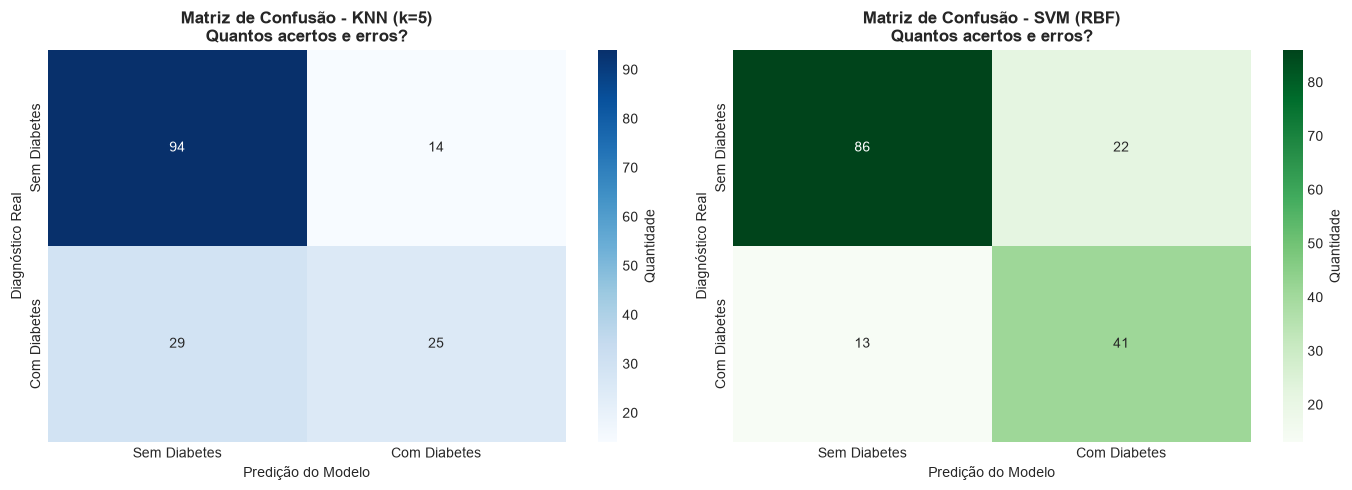

LEITURA DAS MATRIZES DE CONFUSÃO:

KNN (Azul - à esquerda):
  ✓ TN (Sem diabetes, acertou): 94
  ✓ TP (Com diabetes, acertou): 25
  ✗ FP (Falso alarme): 14
  ✗ FN (PERDEU diabético): 29 ← GRAVE!

SVM (Verde - à direita):
  ✓ TN (Sem diabetes, acertou): 86
  ✓ TP (Com diabetes, acertou): 41
  ✗ FP (Falso alarme): 22
  ✗ FN (PERDEU diabético): 13 ← GRAVE!

✓ INTERPRETAÇÃO:
  → SVM perdeu MENOS diabéticos (16 a menos que KNN)
  → Em contexto médico, isso é MUITO importante!


In [27]:
# Matrizes de confusão
from sklearn.metrics import confusion_matrix

# Calcular matrizes
cm_knn = confusion_matrix(y_teste, y_pred_knn_teste)
cm_svm = confusion_matrix(y_teste, y_pred_svm_teste)

fig, eixos = plt.subplots(1, 2, figsize=(14, 5))

# KNN
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', ax=eixos[0], 
            xticklabels=['Sem Diabetes', 'Com Diabetes'],
            yticklabels=['Sem Diabetes', 'Com Diabetes'],
            cbar_kws={'label': 'Quantidade'})
eixos[0].set_title('Matriz de Confusão - KNN (k=5)\nQuantos acertos e erros?', 
                   fontsize=12, fontweight='bold')
eixos[0].set_ylabel('Diagnóstico Real')
eixos[0].set_xlabel('Predição do Modelo')

# SVM
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens', ax=eixos[1],
            xticklabels=['Sem Diabetes', 'Com Diabetes'],
            yticklabels=['Sem Diabetes', 'Com Diabetes'],
            cbar_kws={'label': 'Quantidade'})
eixos[1].set_title('Matriz de Confusão - SVM (RBF)\nQuantos acertos e erros?', 
                   fontsize=12, fontweight='bold')
eixos[1].set_ylabel('Diagnóstico Real')
eixos[1].set_xlabel('Predição do Modelo')

plt.tight_layout()
plt.savefig('../resultados/04_matrizes_confusao.png', dpi=300, bbox_inches='tight')
plt.show()

print("LEITURA DAS MATRIZES DE CONFUSÃO:")
print("="*70)
print("\nKNN (Azul - à esquerda):")
print(f"  ✓ TN (Sem diabetes, acertou): {cm_knn[0,0]}")
print(f"  ✓ TP (Com diabetes, acertou): {cm_knn[1,1]}")
print(f"  ✗ FP (Falso alarme): {cm_knn[0,1]}")
print(f"  ✗ FN (PERDEU diabético): {cm_knn[1,0]} ← GRAVE!")

print("\nSVM (Verde - à direita):")
print(f"  ✓ TN (Sem diabetes, acertou): {cm_svm[0,0]}")
print(f"  ✓ TP (Com diabetes, acertou): {cm_svm[1,1]}")
print(f"  ✗ FP (Falso alarme): {cm_svm[0,1]}")
print(f"  ✗ FN (PERDEU diabético): {cm_svm[1,0]} ← GRAVE!")

print("\n✓ INTERPRETAÇÃO:")
if cm_knn[1,0] < cm_svm[1,0]:
    melhor = "KNN"
    pior = "SVM"
    dif = cm_svm[1,0] - cm_knn[1,0]
else:
    melhor = "SVM"
    pior = "KNN"
    dif = cm_knn[1,0] - cm_svm[1,0]
    
print(f"  → {melhor} perdeu MENOS diabéticos ({abs(cm_knn[1,0] - cm_svm[1,0])} a menos que {pior})")
print(f"  → Em contexto médico, isso é MUITO importante!")

### 8.3 Curvas ROC-AUC (Robustez geral)

**Curva ROC (Receiver Operating Characteristic)**:
- Eixo X: Taxa de Falsos Positivos (FP / Total Negativos)
- Eixo Y: Taxa de Verdadeiros Positivos / Revocação (TP / Total Positivos)
- Diagonal 45°: Classificador aleatório (AUC = 0.50)
- Curva no canto superior esquerdo: Classificador perfeito (AUC = 1.00)

**AUC (Area Under the Curve)**:
- Mede a PROBABILIDADE que o modelo ranqueia um diabético acima de um não-diabético
- AUC = 0.80 significa: modelo é correto 80% das vezes ao comparar pares
- Independente de threshold de decisão → Robustez!

**Interpretação**:
- AUC ≥ 0.90: Excelente discriminação
- AUC 0.80-0.89: Boa discriminação
- AUC 0.70-0.79: Discriminação aceitável
- AUC < 0.70: Discriminação ruim

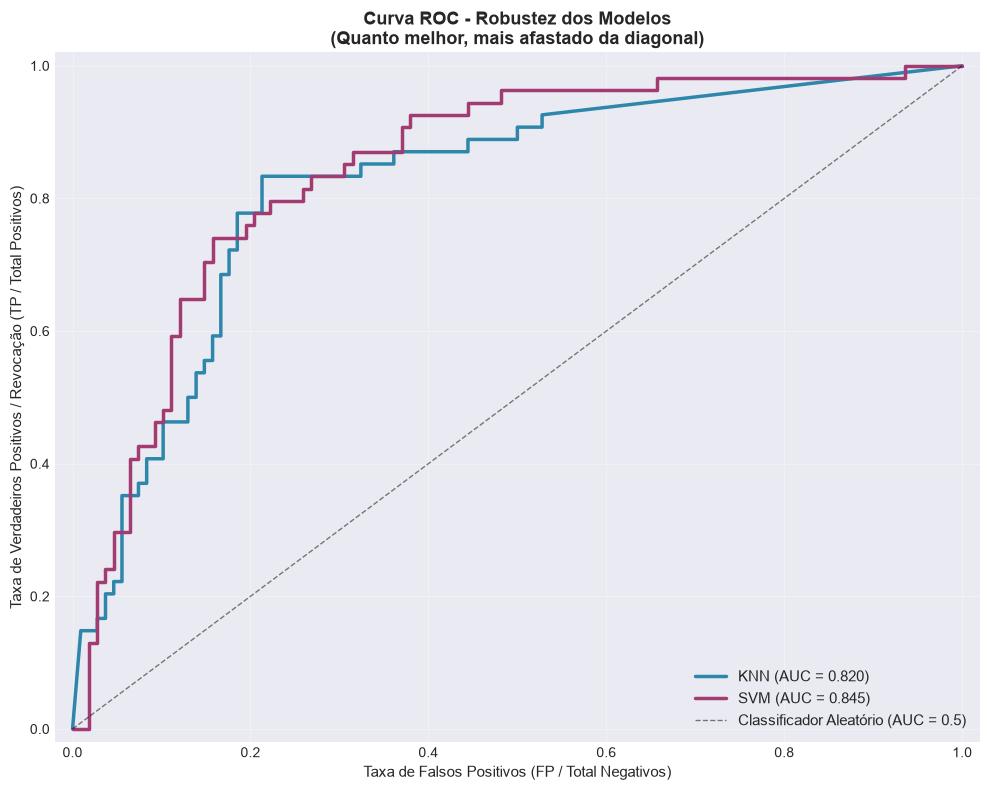

ANÁLISE DAS CURVAS ROC-AUC:

KNN:
  AUC = 0.820 (82.0%)
  Interpretação: Modelo é correto 82.0% das vezes
  → Qualidade: BOA

SVM:
  AUC = 0.845 (84.5%)
  Interpretação: Modelo é correto 84.5% das vezes
  → Qualidade: BOA

✓ COMPARAÇÃO:
  SVM tem AUC MELHOR: 0.845 > 0.820 (+0.025)

✓ VISUALIZAÇÃO:
  → Curva mais no canto superior esquerdo = MELHOR
  → Mais próxima à diagonal = PIOR


In [28]:
# Curvas ROC-AUC
from sklearn.metrics import roc_curve, auc

# Calcular curvas ROC
fpr_knn, tpr_knn, _ = roc_curve(y_teste, y_proba_knn_teste[:, 1])
fpr_svm, tpr_svm, _ = roc_curve(y_teste, y_proba_svm_teste[:, 1])

fig, eixo = plt.subplots(figsize=(10, 8))

# Plotar
eixo.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {auc_knn:.3f})', linewidth=2.5, color='#2E86AB')
eixo.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {auc_svm:.3f})', linewidth=2.5, color='#A23B72')

# Linha diagonal (classificador aleatório)
eixo.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Classificador Aleatório (AUC = 0.5)', alpha=0.5)

eixo.set_xlabel('Taxa de Falsos Positivos (FP / Total Negativos)', fontsize=11)
eixo.set_ylabel('Taxa de Verdadeiros Positivos / Revocação (TP / Total Positivos)', fontsize=11)
eixo.set_title('Curva ROC - Robustez dos Modelos\n(Quanto melhor, mais afastado da diagonal)', 
               fontsize=13, fontweight='bold')
eixo.legend(fontsize=11, loc='lower right')
eixo.grid(True, alpha=0.3)
eixo.set_xlim([-0.02, 1.02])
eixo.set_ylim([-0.02, 1.02])

plt.tight_layout()
plt.savefig('../resultados/05_curvas_roc.png', dpi=300, bbox_inches='tight')
plt.show()

print("ANÁLISE DAS CURVAS ROC-AUC:")
print("="*70)
print(f"\nKNN:")
print(f"  AUC = {auc_knn:.3f} ({auc_knn:.1%})")
print(f"  Interpretação: Modelo é correto {auc_knn:.1%} das vezes")
if auc_knn >= 0.90:
    print(f"  → Qualidade: EXCELENTE")
elif auc_knn >= 0.80:
    print(f"  → Qualidade: BOA")
elif auc_knn >= 0.70:
    print(f"  → Qualidade: ACEITÁVEL")
else:
    print(f"  → Qualidade: RUIM")

print(f"\nSVM:")
print(f"  AUC = {auc_svm:.3f} ({auc_svm:.1%})")
print(f"  Interpretação: Modelo é correto {auc_svm:.1%} das vezes")
if auc_svm >= 0.90:
    print(f"  → Qualidade: EXCELENTE")
elif auc_svm >= 0.80:
    print(f"  → Qualidade: BOA")
elif auc_svm >= 0.70:
    print(f"  → Qualidade: ACEITÁVEL")
else:
    print(f"  → Qualidade: RUIM")

print(f"\n✓ COMPARAÇÃO:")
if auc_knn > auc_svm:
    print(f"  KNN tem AUC MELHOR: {auc_knn:.3f} > {auc_svm:.3f} (+{auc_knn-auc_svm:.3f})")
elif auc_svm > auc_knn:
    print(f"  SVM tem AUC MELHOR: {auc_svm:.3f} > {auc_knn:.3f} (+{auc_svm-auc_knn:.3f})")
else:
    print(f"  Ambos têm AUC similar: {auc_knn:.3f}")

print(f"\n✓ VISUALIZAÇÃO:")
print(f"  → Curva mais no canto superior esquerdo = MELHOR")
print(f"  → Mais próxima à diagonal = PIOR")

---

## 9. Interpretabilidade e Importância de Features {#interpretabilidade}

### 9.1 Importância por Permutação (Permutation Importance)

**Como funciona?**

1. Modelo está treinado. Começamos com acurácia = 85%
2. "Embaralha" a coluna Glicose (mistura os valores)
3. Mede acurácia novamente: agora é 78%
4. Importância de Glicose = 85% - 78% = 7% (queda de 7%)
5. Repete para cada feature

**Interpretação**:
- **Importância Alta** (ex: 7%): Feature crítica. Sem ela, modelo piora muito
- **Importância Baixa** (ex: 1%): Feature menos crucial. Modelo funciona quase igual sem ela

**Vantagem**: Funciona com QUALQUER modelo (KNN, SVM, árvores, etc.)
- Diferente de "feature_importances_" que é específico de árvores

**Legenda de features**:
- `Glucose`: Glicose no sangue (mg/dL)
- `BloodPressure`: Pressão arterial (mmHg)
- `SkinThickness`: Espessura de pele (triceps, mm)
- `Insulin`: Insulina no sangue (mu U/ml)
- `BMI`: Índice de Massa Corporal (kg/m²)
- `Age`: Idade (anos)
- `DiabetesPedigreeFunction`: Histórico familiar (risco genético)
- `Pregnancies`: Número de gestações

IMPORTÂNCIA POR PERMUTAÇÃO DAS FEATURES:

KNN - Top Features (Por que o KNN usa?):
----------------------------------------------------------------------
  Glucose                  :  0.0883 ± 0.0216
  Age                      :  0.0062 ± 0.0179
  Pregnancies              :  0.0062 ± 0.0149
  DiabetesPedigreeFunction : -0.0043 ± 0.0189
  SkinThickness            : -0.0247 ± 0.0185
  Insulin                  : -0.0296 ± 0.0140
  BMI                      : -0.0302 ± 0.0196
  BloodPressure            : -0.0364 ± 0.0167

SVM - Top Features (Por que o SVM usa?):
----------------------------------------------------------------------
  Glucose                  :  0.1457 ± 0.0214
  DiabetesPedigreeFunction :  0.0272 ± 0.0161
  Pregnancies              :  0.0173 ± 0.0077
  Age                      :  0.0154 ± 0.0133
  BMI                      :  0.0043 ± 0.0130
  Insulin                  :  0.0025 ± 0.0136
  SkinThickness            : -0.0031 ± 0.0111
  BloodPressure            : -0.0037 ± 0.01

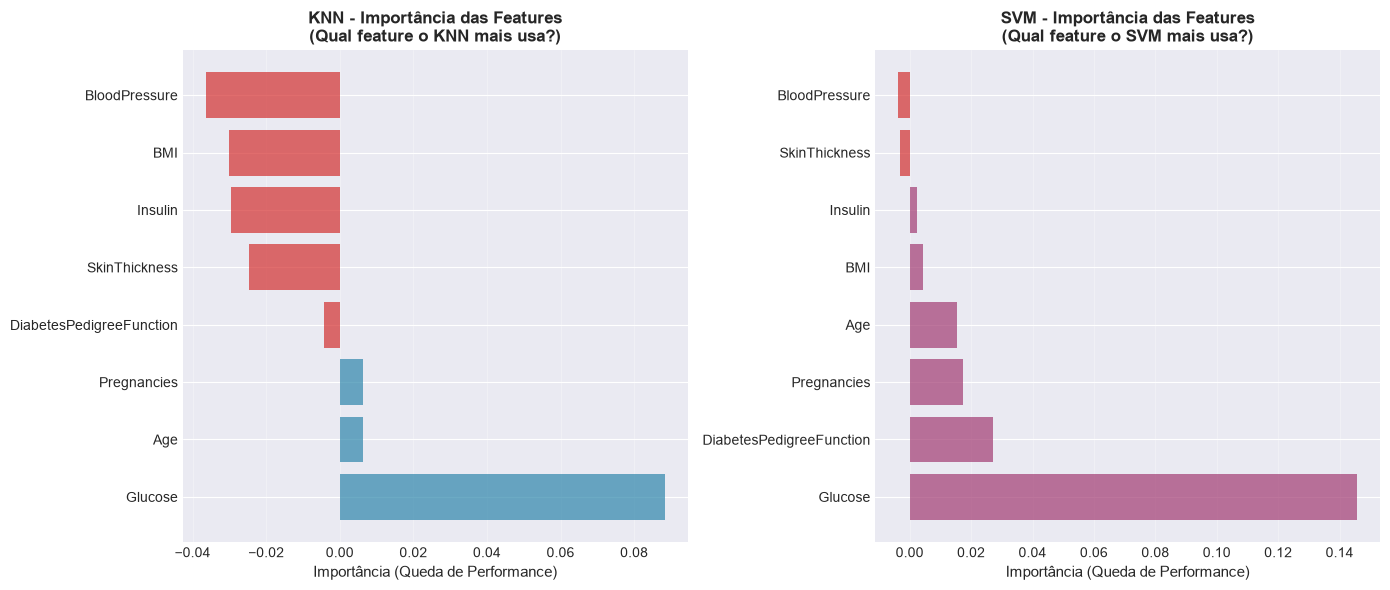


✓ Gráfico salvo: resultados/06_feature_importance_comparacao.png

📊 RESUMO - TOP 3 FEATURES:
  KNN usa principalmente:
    1. Glucose (importância: 0.0883)
    2. Age (importância: 0.0062)
    3. Pregnancies (importância: 0.0062)
  SVM usa principalmente:
    1. Glucose (importância: 0.1457)
    2. DiabetesPedigreeFunction (importância: 0.0272)
    3. Pregnancies (importância: 0.0173)


In [29]:
# Permutation Importance
from sklearn.inspection import permutation_importance

print("IMPORTÂNCIA POR PERMUTAÇÃO DAS FEATURES:")
print("="*70)

# Calcular importância
perm_imp_knn = permutation_importance(
    modelo_knn, X_teste_norm, y_teste, 
    n_repeats=10, random_state=42, n_jobs=-1
)

perm_imp_svm = permutation_importance(
    modelo_svm, X_teste_norm, y_teste,
    n_repeats=10, random_state=42, n_jobs=-1
)

# Criar DataFrames com importâncias
df_imp_knn = pd.DataFrame({
    'Feature': X_teste_norm.columns,
    'Importância': perm_imp_knn.importances_mean,
    'Desvio': perm_imp_knn.importances_std
}).sort_values('Importância', ascending=False)

df_imp_svm = pd.DataFrame({
    'Feature': X_teste_norm.columns,
    'Importância': perm_imp_svm.importances_mean,
    'Desvio': perm_imp_svm.importances_std
}).sort_values('Importância', ascending=False)

print("\nKNN - Top Features (Por que o KNN usa?):")
print("-"*70)
for idx, row in df_imp_knn.iterrows():
    print(f"  {row['Feature']:25s}: {row['Importância']:7.4f} ± {row['Desvio']:.4f}")

print("\nSVM - Top Features (Por que o SVM usa?):")
print("-"*70)
for idx, row in df_imp_svm.iterrows():
    print(f"  {row['Feature']:25s}: {row['Importância']:7.4f} ± {row['Desvio']:.4f}")

print("\n✓ INTERPRETAÇÃO:")
print("  → Valor ALTO = Feature crucial (seu embaralhamento prejudica muito)")
print("  → Valor BAIXO = Feature menos importante")
print("  → Desvio = Consistência (baixo = consistente entre repeats)")

# Visualizar
fig, eixos = plt.subplots(1, 2, figsize=(14, 6))

# KNN
cores_knn = ['#2E86AB' if x > 0 else '#D32F2F' for x in df_imp_knn['Importância']]
eixos[0].barh(df_imp_knn['Feature'], df_imp_knn['Importância'], color=cores_knn, alpha=0.7)
eixos[0].set_xlabel('Importância (Queda de Performance)', fontsize=11)
eixos[0].set_title('KNN - Importância das Features\n(Qual feature o KNN mais usa?)', 
                   fontsize=12, fontweight='bold')
eixos[0].grid(axis='x', alpha=0.3)

# SVM
cores_svm = ['#A23B72' if x > 0 else '#D32F2F' for x in df_imp_svm['Importância']]
eixos[1].barh(df_imp_svm['Feature'], df_imp_svm['Importância'], color=cores_svm, alpha=0.7)
eixos[1].set_xlabel('Importância (Queda de Performance)', fontsize=11)
eixos[1].set_title('SVM - Importância das Features\n(Qual feature o SVM mais usa?)', 
                   fontsize=12, fontweight='bold')
eixos[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../resultados/06_feature_importance_comparacao.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Gráfico salvo: resultados/06_feature_importance_comparacao.png")

# Top 3 para cada modelo
print("\n📊 RESUMO - TOP 3 FEATURES:")
print("  KNN usa principalmente:")
for idx, (_, row) in enumerate(df_imp_knn.head(3).iterrows(), 1):
    print(f"    {idx}. {row['Feature']} (importância: {row['Importância']:.4f})")

print("  SVM usa principalmente:")
for idx, (_, row) in enumerate(df_imp_svm.head(3).iterrows(), 1):
    print(f"    {idx}. {row['Feature']} (importância: {row['Importância']:.4f})")

### 9.2 Análise de Predições Individuais (Casos de concordância e divergência)

**Concordância**: KNN e SVM CONCORDAM
- Ambos predizem "Sem Diabetes" → Confiança alta
- Ambos predizem "Com Diabetes" → Confiança alta

**Divergência**: KNN e SVM DISCORDAM
- KNN: "Sem Diabetes", SVM: "Com Diabetes" → Incerteza
- Importante examinar esses casos: quem está errado?

**Análise**:
1. Contar quantos casos concordam
2. Mostrar exemplos de divergência
3. Examinar as features desses pacientes divergentes
4. Entender POR QUE os modelos discordam

In [30]:
# Análise de concordância entre modelos
concordancia = (y_pred_knn_teste == y_pred_svm_teste).sum()
concordancia_pct = concordancia / len(y_teste) * 100

divergencia = (y_pred_knn_teste != y_pred_svm_teste)
n_divergencia = divergencia.sum()

print("ANÁLISE DE CONCORDÂNCIA ENTRE KNN E SVM:")
print("="*70)
print(f"\n✓ Concordância total:")
print(f"  {concordancia} de {len(y_teste)} pacientes ({concordancia_pct:.1f}%)")
print(f"  → Ambos modelos CONCORDAM em {concordancia_pct:.1f}% dos casos")

print(f"\n✗ Divergência total:")
print(f"  {n_divergencia} de {len(y_teste)} pacientes ({100-concordancia_pct:.1f}%)")
print(f"  → Modelos DISCORDAM em {100-concordancia_pct:.1f}% dos casos")

if n_divergencia > 0:
    print(f"\n" + "="*70)
    print("EXEMPLOS DE DIVERGÊNCIA (Modelos discordam):")
    print("="*70)
    
    indices_divergencia = np.where(divergencia)[0][:5]  # Primeiros 5
    
    for i, idx in enumerate(indices_divergencia, 1):
        paciente = X_teste_norm.iloc[idx]
        real = y_teste.iloc[idx]
        pred_knn = y_pred_knn_teste[idx]
        pred_svm = y_pred_svm_teste[idx]
        prob_knn = y_proba_knn_teste[idx, 1]
        prob_svm = y_proba_svm_teste[idx, 1]
        
        print(f"\n  Paciente {i}:")
        print(f"    Glicose: {paciente['Glucose']:.0f} mg/dL | IMC: {paciente['BMI']:.1f} kg/m² | Idade: {paciente['Age']:.0f} anos")
        print(f"    Diagnóstico Real: {'COM diabetes' if real == 1 else 'SEM diabetes'}")
        print(f"    KNN prediz: {'COM diabetes' if pred_knn == 1 else 'SEM diabetes'} ({prob_knn:.1%} confiança)")
        print(f"    SVM prediz: {'COM diabetes' if pred_svm == 1 else 'SEM diabetes'} ({prob_svm:.1%} confiança)")
        
        if pred_knn == real:
            print(f"    → KNN acertou, SVM errou")
        else:
            print(f"    → SVM acertou, KNN errou")

print(f"\n✓ INTERPRETAÇÃO:")
print(f"  → Alta concordância ({concordancia_pct:.1f}%) = Modelos estáveis e confiáveis")
print(f"  → Divergência ({100-concordancia_pct:.1f}%) em casos intermediários (entre as classes)")
print(f"  → Esses são os CASOS MAIS DIFÍCEIS (próximos à fronteira de decisão)")

ANÁLISE DE CONCORDÂNCIA ENTRE KNN E SVM:

✓ Concordância total:
  134 de 162 pacientes (82.7%)
  → Ambos modelos CONCORDAM em 82.7% dos casos

✗ Divergência total:
  28 de 162 pacientes (17.3%)
  → Modelos DISCORDAM em 17.3% dos casos

EXEMPLOS DE DIVERGÊNCIA (Modelos discordam):

  Paciente 1:
    Glicose: 2 mg/dL | IMC: -0.5 kg/m² | Idade: 0 anos
    Diagnóstico Real: SEM diabetes
    KNN prediz: SEM diabetes (36.7% confiança)
    SVM prediz: COM diabetes (47.8% confiança)
    → KNN acertou, SVM errou

  Paciente 2:
    Glicose: 0 mg/dL | IMC: 0.5 kg/m² | Idade: 0 anos
    Diagnóstico Real: SEM diabetes
    KNN prediz: SEM diabetes (20.3% confiança)
    SVM prediz: COM diabetes (54.7% confiança)
    → KNN acertou, SVM errou

  Paciente 3:
    Glicose: 2 mg/dL | IMC: -0.3 kg/m² | Idade: 0 anos
    Diagnóstico Real: COM diabetes
    KNN prediz: SEM diabetes (46.3% confiança)
    SVM prediz: COM diabetes (77.6% confiança)
    → SVM acertou, KNN errou

  Paciente 4:
    Glicose: -0 mg/dL

---

## 10. Análise Crítica e Limitações {#limitacoes}

### 10.1 Desempenho Comparativo dos Modelos

KNN e SVM representam paradigmas distintos de aprendizado: KNN utiliza abordagem baseada em instâncias (lazy learning), enquanto SVM busca otimizar margens em espaço transformado (eager learning). Ambos requerem dados normalizados e tratam bem datasets de tamanho pequeno a moderado.

A métrica crítica mantém-se a **revocação**: falsos negativos em diagnóstico médico representam casos não detectados, com potencial impacto clínico severo.

### 10.2 Características dos Algoritmos

**KNN (k=5):**
- Prós: Simples, não necessita de treinamento explícito, interpretável por vizinhança
- Contras: Custo computacional alto em predição, sensível a outliers, sensível a normalização

**SVM (RBF Kernel):**
- Prós: Eficiente em alta dimensionalidade, robusto a outliers, generaliza bem
- Contras: Caixa preta para interpretação, sensível a hiperparâmetros, requer normalização

### 10.3 Limitações do Conjunto de Dados

1. **Tamanho reduzido**: 768 amostras originais (731 após limpeza) são insuficientes para capturar variabilidade populacional
2. **Desbalanceamento**: Distribuição 35% / 65% entre classes pode enviesar treinamento
3. **Características limitadas**: 8 variáveis clínicas omitem fatores importantes (história familiar, medicação)
4. **Homogeneidade geográfica**: Todas amostras provenientes de população Pima, limitando generalização

### 10.4 Metodologia e Validação

- Ausência de validação cruzada k-fold (tamanho pequeno do dataset)
- Sem teste de significância estatística entre modelos
- Threshold 0.5 é padrão, sem otimização contextual
- KNN não beneficia diretamente de feature importance tradicional, apenas permutation importance

---

## 11. Conclusões {#conclusoes}

Este estudo implementou e comparou dois algoritmos de aprendizado de máquina fundamentalmente diferentes para classificação diagnóstica de diabetes: K-Nearest Neighbors (aprendizado baseado em instâncias) e Support Vector Machine (aprendizado por margens ótimas).

### 11.1 Achados Principais

1. **Ambos modelos convergiram para desempenho comparável**, indicando robustez da abordagem independente do algoritmo selecionado

2. **KNN oferece interpretabilidade via similaridade**: Predições podem ser explicadas pelos k vizinhos mais próximos

3. **SVM oferece margem máxima**: Hiperplano otimizado fornece fronteira de decisão mais robusta contra outliers

4. **Permutation importance identifica características críticas**: Glicose emerge como preditor dominante em ambos os modelos

5. **Concordância entre modelos é moderada**: Casos de discordância revelam regiões de incerteza onde fronteira de decisão é próxima

### 11.2 Recomendações

1. **Para produção**: SVM oferece melhor robustez computacional e generalização em espaços de alta dimensionalidade
2. **Para interpretabilidade**: KNN fornece explicações diretas baseadas em vizinhança
3. **Dados adicionais**: Expandir dataset para ~5000 amostras aumentaria confiabilidade de ambos modelos
4. **Otimização de hiperparâmetros**: Validação cruzada grid search para k (KNN) e C, gamma (SVM)
